# Nigerian Used-Car Price Prediction (Autochek Nigeria)

**Data:** 9,304 car listings scraped from [autochek.africa/ng/cars-for-sale](https://autochek.africa/ng/cars-for-sale) on 7 October 2026.

**Goal:** understand what drives car prices in the Nigerian online market, then build a model that predicts a car's listed price from its attributes.

**Notebook outline**
1. Setup & data loading
2. Data understanding (structure, missing values, data-quality issues)
3. Data cleaning
4. Exploratory data analysis (EDA) with insights
5. Feature engineering & 70/30 train-test split
6. Model training: 11 algorithms compared
7. Tuning the best model
8. Evaluation of the final model (errors, residuals, feature importance)
9. Summary of findings & recommendations

## 1. Setup & data loading

In [1]:
import warnings, re, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import joblib
from pathlib import Path

# Paths work whether the notebook is run from the repo's notebooks/ folder or next to the CSV
ROOT = Path("..") if Path("../data/autochek_cars_ng.csv").exists() else Path(".")
DATA_DIR = ROOT / "data" if (ROOT / "data").exists() else ROOT
MODEL_DIR = ROOT / "models" if (ROOT / "models").exists() else ROOT

RANDOM_STATE = 42
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Chart style: one consistent, colour-blind-safe palette; light grid; no top/right spines
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984"
PALETTE = [BLUE, ORANGE, AQUA]
plt.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.edgecolor": "#b8b7b1", "axes.titleweight": "bold", "axes.titlesize": 13,
    "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
})
naira_m = mtick.FuncFormatter(lambda v, _: f"₦{v/1e6:,.0f}M")

def log_naira(ax, axis="y"):
    # log scale, naira labels on major ticks only
    a = ax.yaxis if axis == "y" else ax.xaxis
    (ax.set_yscale if axis == "y" else ax.set_xscale)("log")
    a.set_major_formatter(naira_m)
    a.set_minor_formatter(mtick.NullFormatter())

def money(v):
    return f"₦{v/1e6:,.1f}M"

In [2]:
raw = pd.read_csv(DATA_DIR / "autochek_cars_ng.csv")
print(f"Rows: {raw.shape[0]:,}   Columns: {raw.shape[1]}")
raw.head()

Rows: 9,304   Columns: 30


,id,title,year,make,model,price_ngn,old_price_ngn,monthly_installment_ngn,loan_value_ngn,has_financing,condition,mileage,mileage_unit,transmission,fuel_type,engine_type,engine_cc,body_type_id,state,city,grade_score,listing_score,accidented,inspected,has_warranty,is_featured,sold,listed_date,url,image_url
0,c-6oS_5Vu,KIA Sportage,2017,KIA,Sportage,20000000,"20,000,000.00","992,780.00","17,048,958.00",True,foreign,16000,miles,automatic,petrol,4-cylinder,"2,000.00",3,Lagos,Ikeja,3.00,4.30,False,False,False,False,False,2026-10-07T21:54:44.650Z,https://autochek.africa/ng/cars-for-sale/kia/s...,"https://media.autochek.africa/file/w_771,q_100..."
1,CwKoHryd0,Hyundai Elantra,2013,Hyundai,Elantra,11300000,"11,300,000.00","579,836.00","9,843,480.00",True,foreign,0,km,automatic,petrol,4-cylinder,"1,800.00",8,Lagos,NaN,3.00,4.10,False,False,False,False,False,2026-10-07T20:49:18.071Z,https://autochek.africa/ng/cars-for-sale/hyund...,"https://media.autochek.africa/file/w_771,q_100..."
2,HcMNYFInG,Mercedes-Benz GLE-Class,2022,Mercedes-Benz,GLE-Class,150000000,"150,000,000.00","6,959,774.00","125,329,160.00",True,foreign,0,km,automatic,petrol,8-cylinder,"4,000.00",3,Lagos,Idimu,3.00,4.20,False,False,False,False,False,2026-10-07T20:50:00.320Z,https://autochek.africa/ng/cars-for-sale/merce...,"https://media.autochek.africa/file/w_577,q_100..."
3,-Ib61U0Q_,TOYOTA Camry,2022,TOYOTA,Camry,39000000,"39,000,000.00","1,861,972.00","33,274,148.00",True,foreign,0,km,automatic,petrol,4-cylinder,"2,500.00",8,Lagos,Idimu,3.00,4.20,False,False,False,False,False,2026-10-07T20:50:10.538Z,https://autochek.africa/ng/cars-for-sale/toyot...,"https://media.autochek.africa/file/w_577,q_100..."
4,J_lcXRvBc,TOYOTA Tacoma,2018,TOYOTA,Tacoma,36000000,"36,000,000.00","1,742,393.00","30,669,460.00",True,foreign,82000,miles,automatic,petrol,6-cylinder,"6,323.00",1,Lagos,Surulere,3.00,3.90,False,False,False,False,False,2026-10-07T17:38:45.963Z,https://autochek.africa/ng/cars-for-sale/toyot...,"https://media.autochek.africa/file/w_520,q_100..."


## 2. Data understanding

In [3]:
info = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "missing_%": (raw.isna().mean() * 100).round(1),
    "unique": raw.nunique(),
    "example": raw.iloc[0],
})
info

,dtype,missing,missing_%,unique,example
id,str,0,0.00,9304,c-6oS_5Vu
title,str,0,0.00,402,KIA Sportage
year,int64,0,0.00,27,2017
make,str,0,0.00,55,KIA
model,str,1,0.00,399,Sportage
price_ngn,int64,0,0.00,949,20000000
old_price_ngn,float64,0,0.00,947,"20,000,000.00"
monthly_installment_ngn,float64,0,0.00,7278,"992,780.00"
loan_value_ngn,float64,0,0.00,6269,"17,048,958.00"
has_financing,bool,0,0.00,2,True


In [4]:
raw[["price_ngn", "year", "mileage", "engine_cc", "grade_score"]].describe(percentiles=[.01, .25, .5, .75, .99]).T

,count,mean,std,min,1%,25%,50%,75%,99%,max
price_ngn,"9,304.00","75,047,857.36","3,663,267,146.76",20.00,"5,152,470.00","12,000,000.00","17,992,500.00","31,000,000.00","230,000,000.00","349,999,988,736.00"
year,"9,304.00","2,014.27",4.25,"1,999.00","2,005.00","2,011.00","2,014.00","2,017.00","2,025.00","2,026.00"
mileage,"9,304.00","224,720.63","12,055,913.78",0.00,0.00,"30,102.25","83,441.00","120,000.00","431,770.77","1,160,262,352.00"
engine_cc,"1,858.00","43,652.77","830,356.89",0.00,2.00,"2,000.00","2,500.00","3,500.00","55,345.51","25,274,477.00"
grade_score,"9,304.00",3.18,0.41,1.20,2.60,3.00,3.00,3.00,4.50,5.00


In [5]:
# Are the finance columns just functions of price? (if so they leak the target)
raw[["price_ngn", "old_price_ngn", "monthly_installment_ngn", "loan_value_ngn"]].corr().round(4)

,price_ngn,old_price_ngn,monthly_installment_ngn,loan_value_ngn
price_ngn,1.00,1.00,1.00,1.00
old_price_ngn,1.00,1.00,1.00,1.00
monthly_installment_ngn,1.00,1.00,1.00,1.00
loan_value_ngn,1.00,1.00,1.00,1.00


In [6]:
print("Price extremes (cheapest 3 and most expensive 8 listings):")
display(pd.concat([raw.nsmallest(3, "price_ngn"), raw.nlargest(8, "price_ngn")])[["title", "year", "condition", "price_ngn"]])

print("Inconsistent labels, e.g. make & state spellings:")
print(raw["make"].value_counts().filter(regex="TOYOTA|RANGE|KIA|Toyota").to_dict())
print(raw["state"].value_counts(dropna=False).head(12).to_dict())

Price extremes (cheapest 3 and most expensive 8 listings):


,title,year,condition,price_ngn
346,Mercedes-Benz C-Class,2016,foreign,20
3826,KIA Picanto,2007,local,2500000
31,Peugeot 307,2008,local,3000000
5115,Cadillac Escalade ESV,2024,foreign,349999988736
801,Mercedes-Benz GLC 300,2020,foreign,44999999488
6152,TOYOTA Sienna,2012,foreign,16300000256
2533,TOYOTA Highlander,2006,foreign,8700000256
9201,Mercedes-Benz GLE 63 AMG,2020,local,1650029952
4263,Rolls-Royce Cullinan,2025,foreign,1000000000
4249,Rolls-Royce Cullinan,2023,foreign,900000000


Inconsistent labels, e.g. make & state spellings:
{'TOYOTA': 4212, 'KIA': 52, 'TOYOTA LANDCRUISER': 28, 'RANGE ROVER': 19}
{'Lagos': 5960, nan: 2012, 'Abuja': 1140, 'Lagos State': 104, 'Port Harcourt': 43, 'Oyo': 11, 'Rivers': 10, 'Kaduna': 4, 'Kano': 3, 'Ogun': 3, 'Federal Capital Territory': 2, 'Ogun State': 2}


**Observations (data understanding)**

- **9,304 listings × 30 columns.** Each row is one car for sale, described by make/model, year, condition, mileage, engine, body type, location, financing details and the listed price (`price_ngn`), which is our **target**.
- **Target leakage found:** `old_price_ngn`, `monthly_installment_ngn` and `loan_value_ngn` correlate **1.00** with price, because the site calculates them *from* the price. Using them would let the model "cheat", so they are removed.
- **Data-entry errors in price:** the cheapest "car" is listed at **₦20** and the most expensive at **₦350 billion** (a 2024 Escalade). Several values such as ₦16,300,000,256 for a 2012 Sienna look like extra zeros or number-format glitches.
- **Mostly-empty columns:** `engine_cc` (80% missing), `listing_score`, `accidented` and `is_featured` (~79% missing) carry too little information to use. `sold` is the same (False) for every row.
- **Inconsistent labels:** the same make appears as `TOYOTA` / `TOYOTA LANDCRUISER`; states appear as `Lagos` / `Lagos State` / missing (21.6%).
- **Mileage is mixed-unit** (68% in miles, 32% in km), and contains impossible values (up to 1.16 billion), plus 0 km on many used cars, which really means "not recorded".

## 3. Data cleaning

In [7]:
df = raw.copy()
log = []  # cleaning log: (step, rows remaining)
log.append(("Raw data", len(df)))

# 3.1 Remove duplicate listings (same car re-posted: same title, year, price, mileage, condition, state)
dup_key = ["title", "year", "price_ngn", "mileage", "condition", "state"]
df = df.drop_duplicates(subset=dup_key).copy()
log.append(("Drop duplicate listings", len(df)))

# 3.2 Drop columns that leak the target, are identifiers, are constant, or are mostly empty
leakage = ["old_price_ngn", "monthly_installment_ngn", "loan_value_ngn"]   # calculated from price (corr ≈ 1.0)
ids     = ["id", "url", "image_url", "title"]
const   = ["sold"]                                                          # every value is False
sparse  = ["engine_cc", "listing_score", "accidented", "is_featured"]       # 79–80% missing
df = df.drop(columns=leakage + ids + const + sparse)

# 3.3 Standardise make names and fold sub-brands into their manufacturer
def clean_make(m):
    m = str(m).strip()
    special = {"TOYOTA LANDCRUISER": "Toyota", "RANGE ROVER": "Land Rover", "MINI": "Mini"}
    keep_upper = {"BMW", "GMC", "BYD", "JAC", "GAC", "JMC", "MG", "RAM"}
    if m in special: return special[m]
    if m in keep_upper: return m
    return m.title() if (m.isupper() or m.islower()) else m

df["model"] = df["model"].fillna("Unknown").str.strip()
df.loc[raw.loc[df.index, "make"].eq("TOYOTA LANDCRUISER"), "model"] = "Land Cruiser"
df.loc[raw.loc[df.index, "make"].eq("RANGE ROVER"), "model"] = "Range Rover " + df["model"]
df["make"] = df["make"].map(clean_make)
# Model names: unify case/spacing so "RAV 4" == "RAV4", "F 150" == "F-150"
df["model"] = (df["model"].str.upper().str.replace(r"[\s\-]+", "", regex=True))

# 3.4 Standardise states (Lagos State -> Lagos, FCT -> Abuja, Port Harcourt -> Rivers); missing -> Unknown
state_map = {"Lagos State": "Lagos", "Federal Capital Territory": "Abuja", "Port Harcourt": "Rivers",
             "Ogun State": "Ogun", "Rivers State": "Rivers"}
df["state"] = df["state"].str.strip().replace(state_map).fillna("Unknown")
df.loc[~df["state"].isin(["Lagos", "Abuja", "Rivers", "Unknown"]), "state"] = "Other"

# 3.5 Body type: the site stores an ID; label the main ones from the models they contain
body_map = {8: "Sedan", 3: "SUV", 2: "Minivan", 1: "Pickup", 5: "Hatchback/Wagon", 7: "Coupe/Sports", 9: "Van/Bus"}
df["body_type"] = df["body_type_id"].map(body_map).fillna("Other")
df = df.drop(columns=["body_type_id"])

# 3.6 Engine: number of cylinders from "6-cylinder"
df["cylinders"] = df["engine_type"].str.extract(r"(\d+)").astype(float)
df = df.drop(columns=["engine_type"])

# 3.7 Mileage: convert everything to km; 0 km on a used car and > 1,000,000 km are not credible -> missing
df["mileage_km"] = np.where(df["mileage_unit"].eq("miles"), df["mileage"] * 1.60934, df["mileage"])
bad_mileage = (df["mileage_km"] > 1_000_000) | ((df["mileage_km"] == 0) & (df["condition"] != "new"))
df.loc[bad_mileage, "mileage_km"] = np.nan
df = df.drop(columns=["mileage", "mileage_unit"])
print(f"Mileage set to missing for {bad_mileage.sum():,} listings (0 km on used cars or > 1M km)")

# 3.8 Simplify small categories
df["transmission"] = df["transmission"].where(df["transmission"].isin(["automatic", "cvt", "manual"]), "other")
df["fuel_type"] = df["fuel_type"].where(df["fuel_type"].eq("petrol"), "non-petrol")
df["inspected"] = df["inspected"].map({True: "yes", False: "no", "True": "yes", "False": "no"}).fillna("unknown")
df["has_financing"] = df["has_financing"].astype(int)
df["has_warranty"] = df["has_warranty"].astype(int)

# 3.9 Dates & age
df["listed_date"] = pd.to_datetime(df["listed_date"], utc=True)
df["car_age"] = 2026 - df["year"]

Mileage set to missing for 247 listings (0 km on used cars or > 1M km)


In [8]:
# 3.10 Remove price errors.
#  (a) absolute floor: nothing on the site credibly sells for under ₦1M
#  (b) relative check: a listing priced > 6x above or below the median for the same make+model
#      (catches typos such as a 2012 Sienna at ₦16.3 billion, or a ₦45 billion GLC 300)
df["make_model"] = df["make"] + " " + df["model"]
grp_median = df.groupby("make_model")["price_ngn"].transform("median")
grp_size = df.groupby("make_model")["price_ngn"].transform("size")
ratio = df["price_ngn"] / grp_median
too_low = df["price_ngn"] < 1_000_000
off_group = (grp_size >= 3) & ((ratio > 6) | (ratio < 1/6))
too_high = df["price_ngn"] > 2_000_000_000

removed = df[too_low | off_group | too_high]
print(f"Removing {len(removed)} listings with implausible prices:")
display(removed[["make", "model", "year", "condition", "price_ngn"]].assign(model_median=grp_median[removed.index]))
df = df[~(too_low | off_group | too_high)].copy()
log.append(("Drop implausible prices", len(df)))

Removing 21 listings with implausible prices:


,make,model,year,condition,price_ngn,model_median
135,Toyota,CAMRY,2025,foreign,76000000,"12,500,000.00"
297,Land Rover,RANGEROVERSPORT,2024,foreign,180000000,"28,015,000.00"
346,Mercedes-Benz,CCLASS,2016,foreign,20,"19,000,000.00"
736,Toyota,HIACE,2025,new,215000000,"24,000,000.00"
801,Mercedes-Benz,GLC300,2020,foreign,44999999488,"35,030,000.00"
2533,Toyota,HIGHLANDER,2006,foreign,8700000256,"27,500,000.00"
2655,Audi,Q7,2013,local,5800000,"45,000,000.00"
3340,Infiniti,QX80,2025,new,320000000,"35,200,000.00"
3485,Toyota,PRADO,2009,local,9000000,"64,500,000.00"
5082,Toyota,CAMRY,2026,new,80000000,"12,500,000.00"


In [9]:
print(pd.DataFrame(log, columns=["step", "rows"]).to_string(index=False))
print(f"\nFinal cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("\nMissing values remaining:")
print(df.isna().sum()[lambda s: s > 0])
df.to_csv(DATA_DIR / "autochek_cars_ng_clean.csv", index=False)
df.head()

                   step  rows
               Raw data  9304
Drop duplicate listings  9251
Drop implausible prices  9230

Final cleaned dataset: 9,230 rows x 19 columns

Missing values remaining:
city          2590
cylinders        3
mileage_km     247
dtype: int64


,year,make,model,price_ngn,has_financing,condition,transmission,fuel_type,state,city,grade_score,inspected,has_warranty,listed_date,body_type,cylinders,mileage_km,car_age,make_model
0,2017,Kia,SPORTAGE,20000000,1,foreign,automatic,petrol,Lagos,Ikeja,3.00,no,0,2026-10-07 21:54:44.650000+00:00,SUV,4.00,"25,749.44",9,Kia SPORTAGE
1,2013,Hyundai,ELANTRA,11300000,1,foreign,automatic,petrol,Lagos,NaN,3.00,no,0,2026-10-07 20:49:18.071000+00:00,Sedan,4.00,NaN,13,Hyundai ELANTRA
2,2022,Mercedes-Benz,GLECLASS,150000000,1,foreign,automatic,petrol,Lagos,Idimu,3.00,no,0,2026-10-07 20:50:00.320000+00:00,SUV,8.00,NaN,4,Mercedes-Benz GLECLASS
3,2022,Toyota,CAMRY,39000000,1,foreign,automatic,petrol,Lagos,Idimu,3.00,no,0,2026-10-07 20:50:10.538000+00:00,Sedan,4.00,NaN,4,Toyota CAMRY
4,2018,Toyota,TACOMA,36000000,1,foreign,automatic,petrol,Lagos,Surulere,3.00,no,0,2026-10-07 17:38:45.963000+00:00,Pickup,6.00,"131,965.88",8,Toyota TACOMA


**Cleaning summary**

| Step | Action | Why |
|---|---|---|
| Duplicates | Removed **53** re-posted listings (same title, year, price, mileage, condition, state) | Prevents the same car appearing in both the training and test sets |
| Leakage | Dropped 3 finance columns calculated from price | They reveal the answer |
| Sparse/constant/ID columns | Dropped `engine_cc`, `listing_score`, `accidented`, `is_featured`, `sold`, IDs, URLs | No usable signal |
| Make / model | Standardised case; folded *Toyota Landcruiser → Toyota*, *Range Rover → Land Rover*; unified model spellings (e.g. `RAV 4` = `RAV4`) | One label per real-world category |
| State | Merged spellings; grouped small states as *Other*; missing → *Unknown* | Consistent location groups |
| Body type | Translated the site's numeric code into Sedan / SUV / Pickup / Minivan, etc. (inferred from the models in each code) | Readable and usable |
| Mileage | Converted miles → km; **247** impossible values (0 km on used cars, > 1M km) set to missing and imputed later | Comparable units; no fake zeros |
| Price errors | Removed **21** listings priced under ₦1M, over ₦2B, or more than 6× above/below the median of the same model | Typos would distort both EDA and the model |

**Result: 9,230 clean listings (99.2% of the raw data kept).**

## 4. Exploratory data analysis

### 4.1 The target: price distribution

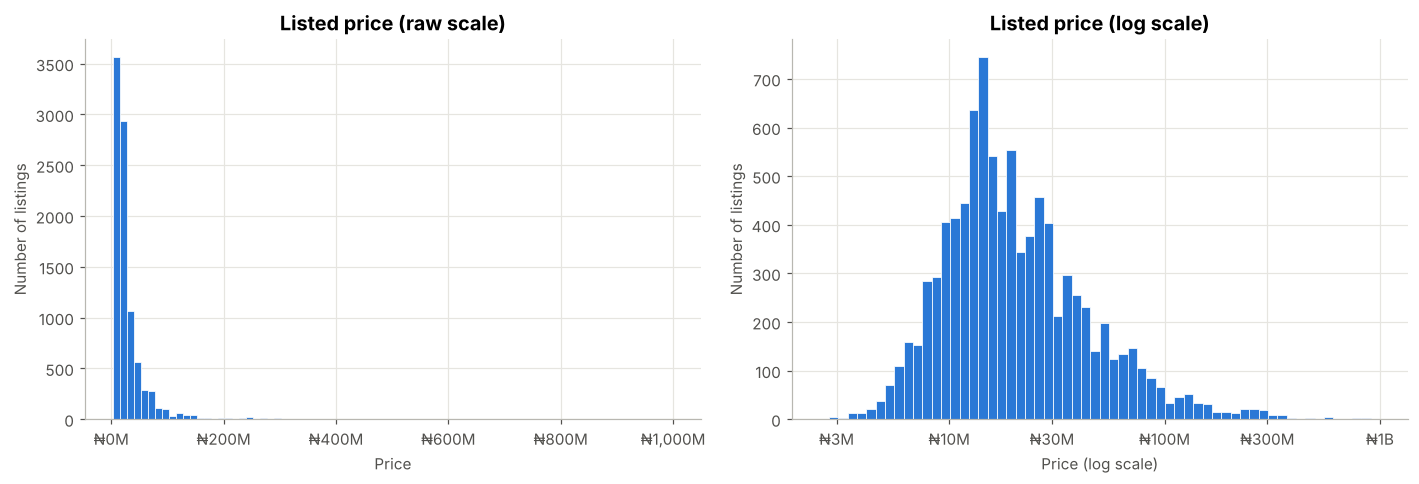

Median ₦17.9M | Mean ₦29.7M | Skewness 7.91 (log-price skewness 0.84)
Price bands:
price_ngn
<₦5M        1.0%
₦5–10M     15.9%
₦10–20M    40.7%
₦20–40M    25.2%
₦40–80M    11.9%
>₦80M       5.3%
Name: proportion, dtype: str


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df["price_ngn"], bins=80, color=BLUE, edgecolor="white", linewidth=0.5)
axes[0].xaxis.set_major_formatter(naira_m)
axes[0].set(title="Listed price (raw scale)", xlabel="Price", ylabel="Number of listings")
axes[1].hist(np.log10(df["price_ngn"]), bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
axes[1].set_xticks(np.log10([3e6, 1e7, 3e7, 1e8, 3e8, 1e9]))
axes[1].set_xticklabels(["₦3M", "₦10M", "₦30M", "₦100M", "₦300M", "₦1B"])
axes[1].set(title="Listed price (log scale)", xlabel="Price (log scale)", ylabel="Number of listings")
plt.tight_layout(); plt.show()

p = df["price_ngn"]
print(f"Median {money(p.median())} | Mean {money(p.mean())} | Skewness {p.skew():.2f} (log-price skewness {np.log(p).skew():.2f})")
print("Price bands:")
bands = pd.cut(p, [0, 5e6, 10e6, 20e6, 40e6, 80e6, np.inf], labels=["<₦5M", "₦5–10M", "₦10–20M", "₦20–40M", "₦40–80M", ">₦80M"])
print((bands.value_counts(normalize=True).sort_index() * 100).round(1).astype(str) + "%")

**Insights: price distribution**

- The **median car costs ₦17.9M**, but the **mean is ₦29.7M**. A small number of luxury vehicles pull the average up, so the median is the better "typical price".
- Prices are **heavily right-skewed** (skewness 7.9). On a log scale the distribution becomes close to bell-shaped (skewness 0.8). **This is why the models learn `log(price)`** and convert predictions back to naira.
- **2 in 3 cars (66%) are listed between ₦10M and ₦40M**, and ₦10–20M alone is 41% of the market. Only 1% are under ₦5M, and 5% are above ₦80M.

### 4.2 Market composition: makes, models, condition, body type, location

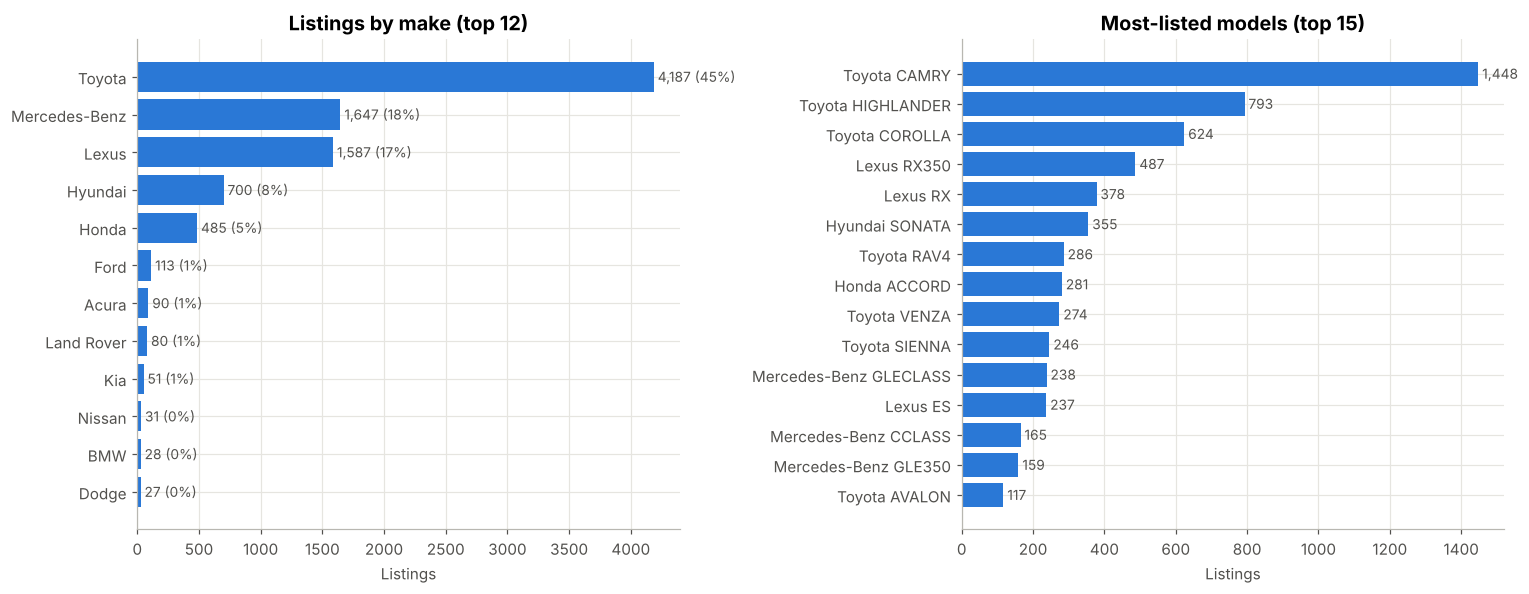

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
top_makes = df["make"].value_counts().head(12)
axes[0].barh(top_makes.index[::-1], top_makes.values[::-1], color=BLUE)
axes[0].set(title="Listings by make (top 12)", xlabel="Listings")
for y, v in enumerate(top_makes.values[::-1]):
    axes[0].text(v, y, f" {v:,} ({v/len(df):.0%})", va="center", fontsize=9, color="#52514e")

top_models = df["make_model"].value_counts().head(15)
axes[1].barh(top_models.index[::-1], top_models.values[::-1], color=BLUE)
axes[1].set(title="Most-listed models (top 15)", xlabel="Listings")
for y, v in enumerate(top_models.values[::-1]):
    axes[1].text(v, y, f" {v:,}", va="center", fontsize=9, color="#52514e")
plt.tight_layout(); plt.show()

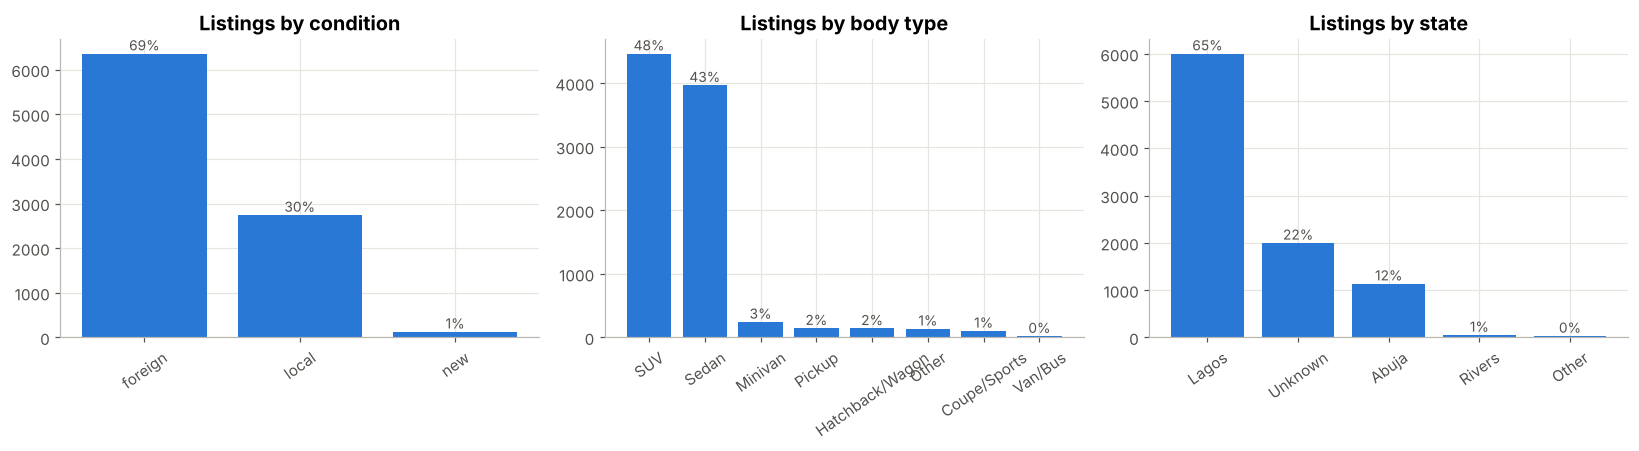

Transmission: {'automatic': 96.6, 'cvt': 2.3, 'manual': 0.8, 'other': 0.3}
Fuel: {'petrol': 99.6, 'non-petrol': 0.4}
Financing available: 97.6%


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col, title in zip(axes, ["condition", "body_type", "state"], ["Condition", "Body type", "State"]):
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color=BLUE)
    ax.set(title=f"Listings by {title.lower()}")
    ax.tick_params(axis="x", rotation=35)
    for x, v in enumerate(vc.values):
        ax.text(x, v, f"{v/len(df):.0%}", ha="center", va="bottom", fontsize=9, color="#52514e")
plt.tight_layout(); plt.show()

print("Transmission:", (df["transmission"].value_counts(normalize=True) * 100).round(1).to_dict())
print("Fuel:", (df["fuel_type"].value_counts(normalize=True) * 100).round(1).to_dict())
print("Financing available:", f"{df['has_financing'].mean():.1%}")

**Insights: what is on the market**

- **Toyota dominates** with ~45% of all listings, followed by **Mercedes-Benz (18%)** and **Lexus (17%)**. These three brands make up **four in five listings**. Hyundai and Honda follow; every other brand is niche.
- The **Toyota Camry alone is ~16% of the market** (1,448 listings), followed by the **Toyota Highlander (~9%)** and **Corolla (~7%)**. The Lexus RX 350, Hyundai Sonata and Honda Accord complete the core.
- **Foreign-used ("tokunbo") cars are 69%** of listings; locally used ("Nigerian-used") are 30%; brand-new cars are just 1.4%.
- **SUVs (48%) and sedans (43%)** make up nine in ten listings.
- **Lagos hosts ~65% of listings** and Abuja ~12%. 22% of listings don't state a location.
- The market is almost entirely **automatic (97%) and petrol (99.6%)**, so these columns barely vary. **97.6% of listings advertise financing**, reflecting Autochek's car-loan business model.

### 4.3 Which makes and models are most expensive?

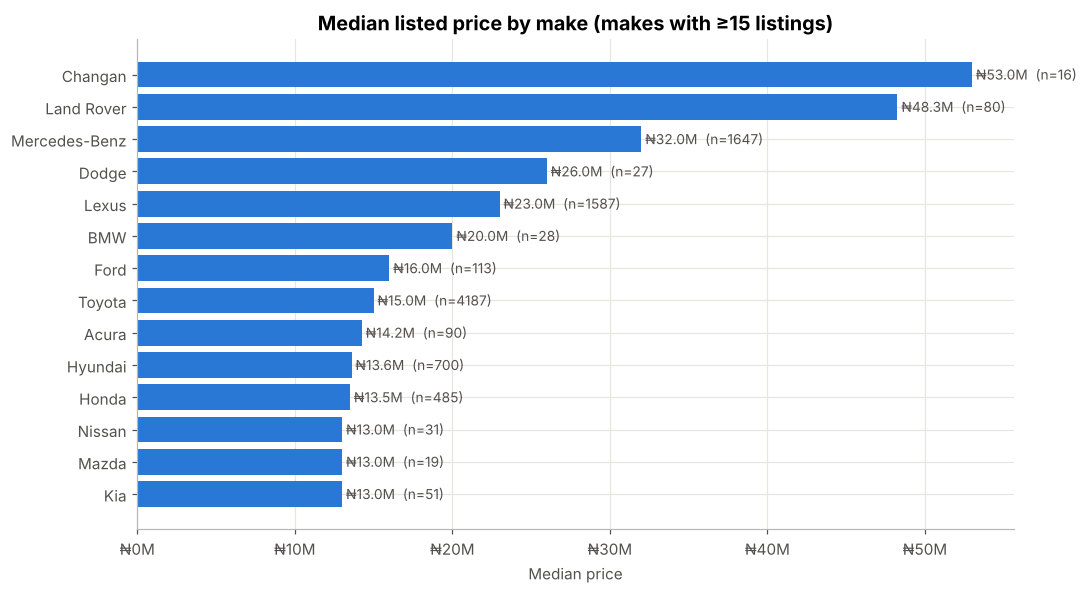

Most expensive popular models (≥20 listings):


,median,count
make_model,,
Mercedes-Benz GCLASS,₦277.0M,24
Mercedes-Benz G63AMG,₦265.0M,34
Mercedes-Benz GLE53AMG,₦129.5M,38
Lexus LX,₦108.0M,21
Lexus LX570,₦90.2M,26
Mercedes-Benz GLE63AMG,₦90.0M,20
Toyota HILUX,₦69.5M,65
Mercedes-Benz GLE450,₦68.0M,32


Most affordable popular models (≥20 listings):


,median,count
make_model,,
Toyota COROLLAMATRIX,₦8.2M,32
Toyota COROLLA,₦11.4M,624
Hyundai ELANTRA,₦11.5M,113
Honda CIVIC,₦12.0M,45
Toyota CAMRY,₦12.5M,1448
Honda ACCORD,₦12.8M,281
Lexus IS,₦13.0M,66
Hyundai SONATA,₦13.0M,355


In [13]:
mk = df.groupby("make")["price_ngn"].agg(["median", "count"]).query("count >= 15").sort_values("median")
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(mk.index, mk["median"], color=BLUE)
ax.xaxis.set_major_formatter(naira_m)
ax.set(title="Median listed price by make (makes with ≥15 listings)", xlabel="Median price")
for y, (m, n) in enumerate(zip(mk["median"], mk["count"])):
    ax.text(m, y, f" {money(m)}  (n={n})", va="center", fontsize=9, color="#52514e")
plt.tight_layout(); plt.show()

mm = df.groupby("make_model")["price_ngn"].agg(["median", "count"]).query("count >= 20")
print("Most expensive popular models (≥20 listings):")
display(mm.sort_values("median", ascending=False).head(8).style.format({"median": money}))
print("Most affordable popular models (≥20 listings):")
display(mm.sort_values("median").head(8).style.format({"median": money}))

**Insights: brand and model pricing**

- **Luxury brands command a large premium:** **Land Rover (₦48M median)** and **Mercedes-Benz (₦32M)** cost **2–3× more than Toyota (₦15M), Hyundai and Honda (~₦13.5M)**. Lexus (₦23M) sits in between.
- **Changan tops the chart (₦53M)**, but from only 16 listings, almost all recent-model Chinese SUVs. This is a sign of the **growing presence of new Chinese brands** at the upper-middle of the market, rather than a luxury premium.
- **The G-Class / G63 AMG (~₦265–277M median)** and **GLE 53 AMG (~₦130M)** are the most expensive commonly-listed models. The **Lexus LX** and **Toyota Hilux** (~₦70M) show that big 4×4s and pickups hold high prices too.
- **The cheapest common models** are the Corolla Matrix (~₦8M), Corolla, Elantra, Civic, Camry and Accord (₦11–13M). These are mass-market sedans that are also the most-listed, i.e. the volume of the market is in affordable sedans.
- A Lexus IS appears among the "affordable" models because most listed units are older model years. **Brand alone does not set price: age matters just as much** (next section).

### 4.4 Age, year and depreciation

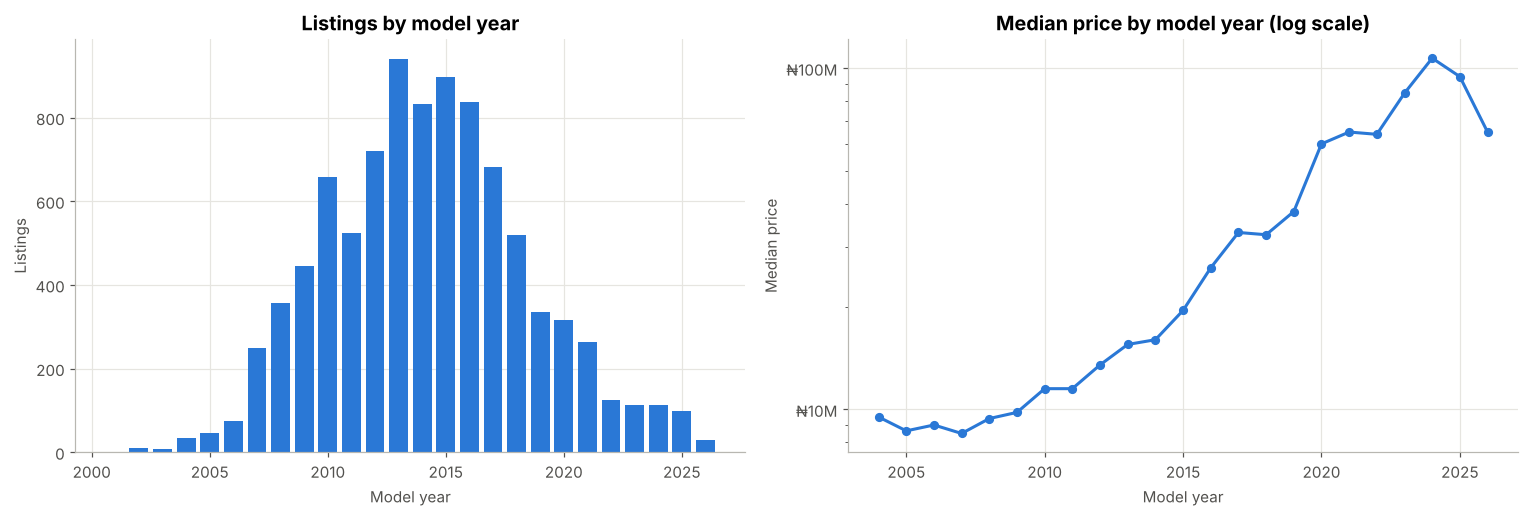

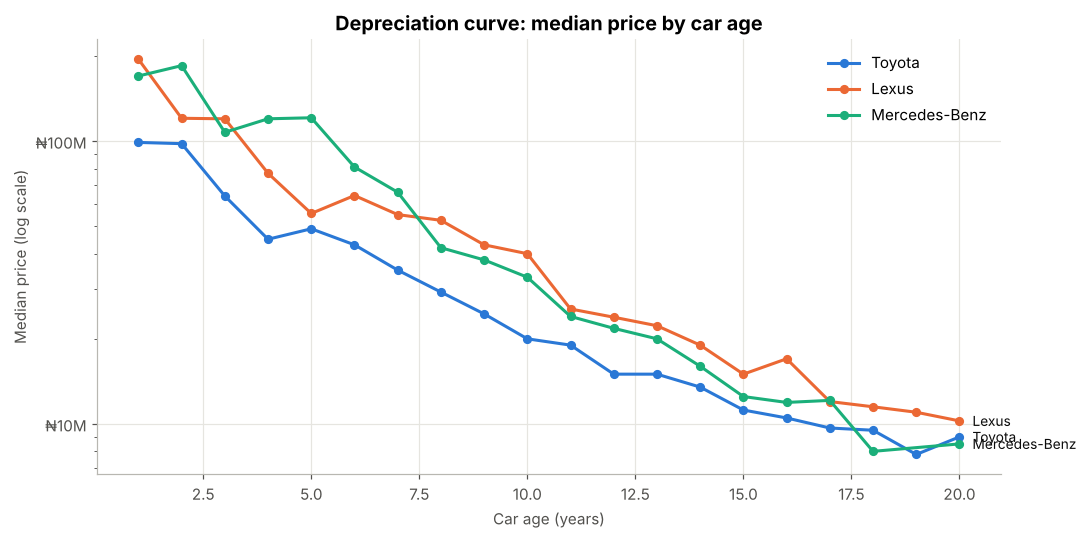

Toyota         loses about 12.0% of its value per year of age
Lexus          loses about 13.9% of its value per year of age
Mercedes-Benz  loses about 18.7% of its value per year of age
Honda          loses about 12.6% of its value per year of age
Hyundai        loses about 11.5% of its value per year of age
Correlation of age with log-price: -0.79


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
yc = df["year"].value_counts().sort_index()
axes[0].bar(yc.index, yc.values, color=BLUE)
axes[0].set(title="Listings by model year", xlabel="Model year", ylabel="Listings")

by_year = df[df["year"] >= 2004].groupby("year")["price_ngn"].median()
axes[1].plot(by_year.index, by_year.values, color=BLUE, linewidth=2, marker="o", markersize=5)
log_naira(axes[1])
axes[1].set(title="Median price by model year (log scale)", xlabel="Model year", ylabel="Median price")
plt.tight_layout(); plt.show()

# Depreciation for the three biggest makes: median price by car age
fig, ax = plt.subplots(figsize=(10, 5))
for make, color in zip(["Toyota", "Lexus", "Mercedes-Benz"], PALETTE):
    s = df[(df["make"] == make) & (df["car_age"].between(1, 20))].groupby("car_age")["price_ngn"].median()
    ax.plot(s.index, s.values, color=color, linewidth=2, marker="o", markersize=5, label=make)
    ax.text(s.index[-1] + 0.3, s.values[-1], make, color="#0b0b0b", va="center", fontsize=9)
log_naira(ax)
ax.set(title="Depreciation curve: median price by car age", xlabel="Car age (years)", ylabel="Median price (log scale)")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

# Average yearly depreciation from a log-linear fit on age (used cars aged 1–20)
used = df[df["car_age"].between(1, 20)]
for make in ["Toyota", "Lexus", "Mercedes-Benz", "Honda", "Hyundai"]:
    d = used[used["make"] == make]
    slope = np.polyfit(d["car_age"], np.log(d["price_ngn"]), 1)[0]
    print(f"{make:<14} loses about {1-np.exp(slope):.1%} of its value per year of age")
print(f"Correlation of age with log-price: {np.corrcoef(df['car_age'], np.log(df['price_ngn']))[0,1]:.2f}")

**Insights: age and depreciation**

- **Age is the single strongest price driver** (correlation of age with log-price **−0.79**). The median price rises steeply with model year: a typical **2010 car is ~₦11M** while a **2020 car is ~₦60M**.
- Most listings are **2010–2017 models** (peak in 2013). Very new cars are scarce, reflecting Nigeria's import age restrictions/tariffs and buyers' budgets.
- **Depreciation rates (value lost per year of age):**
  - Hyundai ~11.5%, Toyota ~12%, Honda ~12.6%: the mass-market brands **hold their value best**.
  - Lexus ~14%.
  - **Mercedes-Benz ~19%**: the steepest. A Mercedes loses value much faster than a Toyota, which matches its higher maintenance costs and parts availability concerns in Nigeria.
- Practical takeaway: **a 5–8-year-old Toyota/Lexus is the value sweet spot**. The steepest absolute loss happens in the first years, while the brands' reputation for reliability keeps resale value up.

### 4.5 Mileage

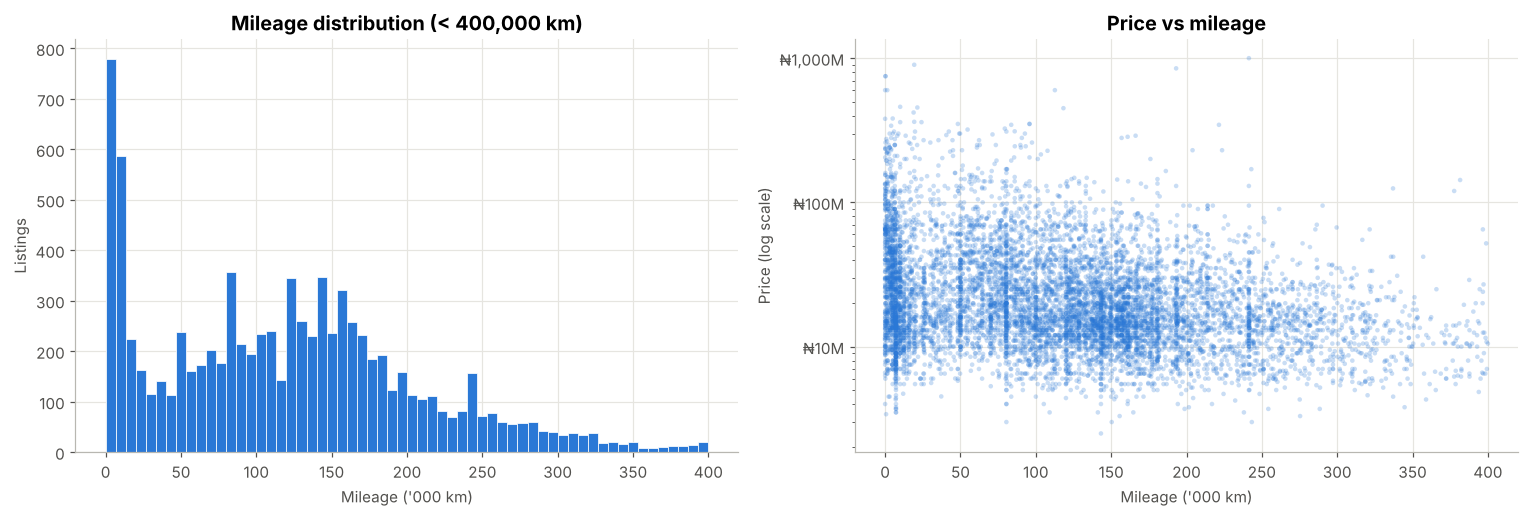

Median price by mileage band (km):
            median  count
mileage_km               
<50k        ₦22.5M   2296
50–100k     ₦23.0M   1586
100–150k    ₦17.0M   1892
150–200k    ₦15.5M   1576
>200k       ₦14.5M   1633

Correlation of mileage with log-price: -0.21
Correlation of mileage with age: 0.20


In [15]:
d = df.dropna(subset=["mileage_km"])
d = d[d["mileage_km"] < 400_000]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].hist(d["mileage_km"] / 1000, bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
axes[0].set(title="Mileage distribution (< 400,000 km)", xlabel="Mileage ('000 km)", ylabel="Listings")

axes[1].scatter(d["mileage_km"] / 1000, d["price_ngn"], s=9, alpha=0.25, color=BLUE, edgecolors="none")
log_naira(axes[1])
axes[1].set(title="Price vs mileage", xlabel="Mileage ('000 km)", ylabel="Price (log scale)")
plt.tight_layout(); plt.show()

mb = pd.cut(df["mileage_km"], [-1, 50e3, 100e3, 150e3, 200e3, np.inf], labels=["<50k", "50–100k", "100–150k", "150–200k", ">200k"])
print("Median price by mileage band (km):")
print(df.groupby(mb, observed=True)["price_ngn"].agg(["median", "count"]).assign(median=lambda x: x["median"].map(money)))
print(f"\nCorrelation of mileage with log-price: {df[['mileage_km']].assign(lp=np.log(df['price_ngn'])).corr().iloc[0,1]:.2f}")
print(f"Correlation of mileage with age: {df[['mileage_km','car_age']].corr().iloc[0,1]:.2f}")

**Insights: mileage**

- Typical mileage is **80–150k km**. Mileage reduces price, but **much less than expected**: correlation with log-price is only **−0.21**.
- Cars under 100k km sell at a median of ~₦22–23M versus ~₦15M above 150k km. However, **mileage and age are only weakly correlated (0.20)** in this data, which is unusual (older cars normally have more km).
- This suggests **listed mileage is often unreliable** (odometer rollback is a known problem in imported used cars), so buyers and the model rely more on **year** than on the odometer.

### 4.6 Condition, body type, engine and location vs price

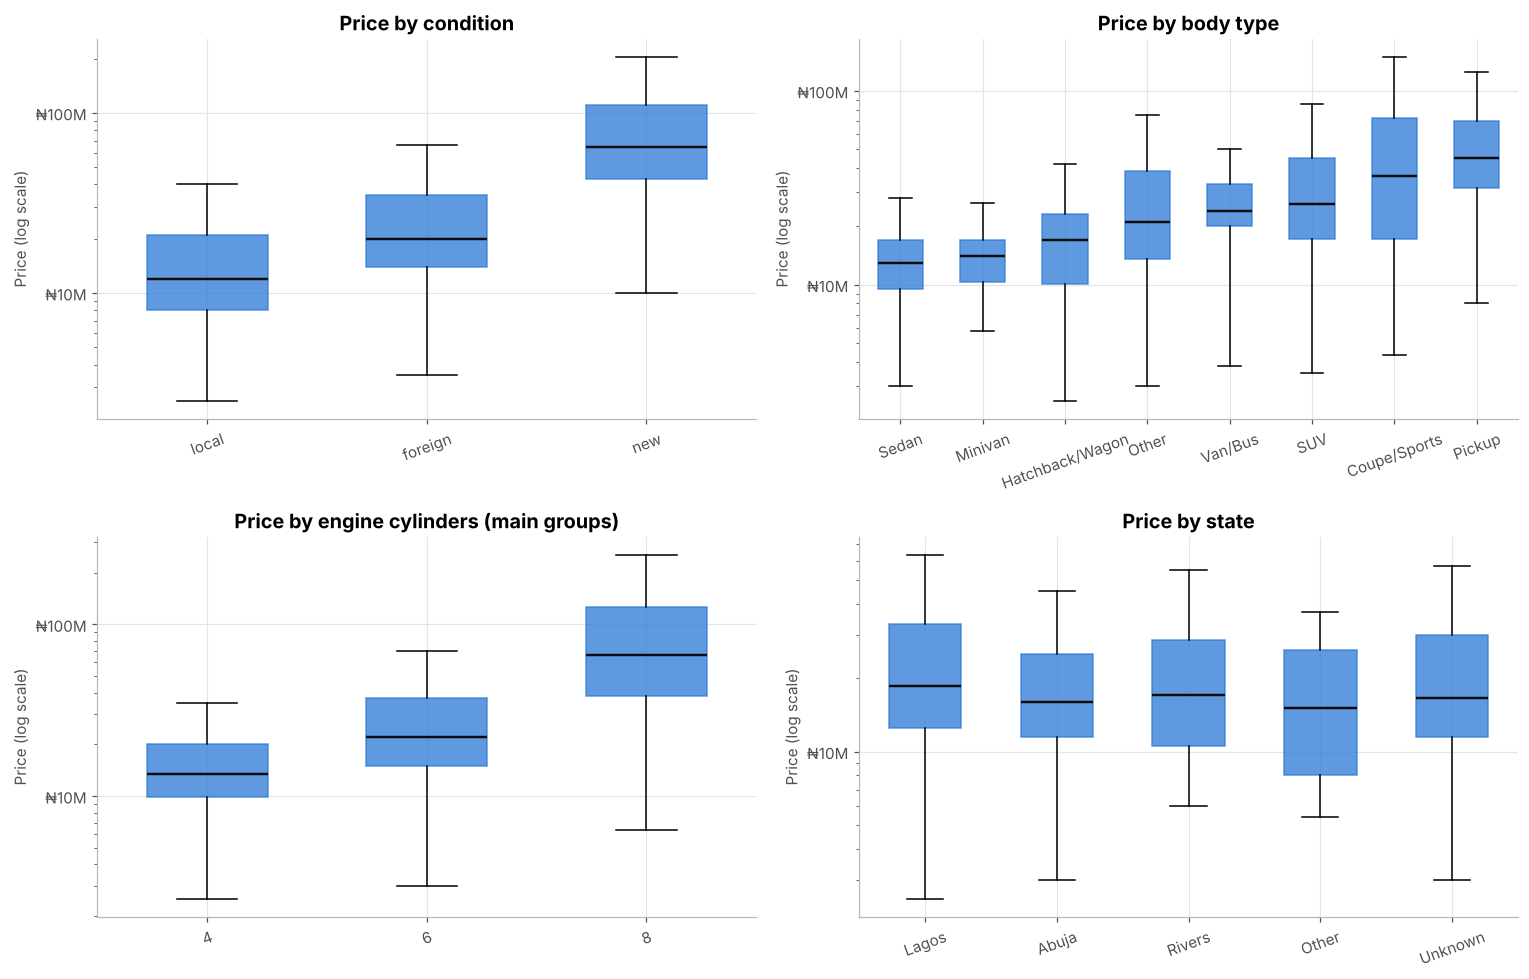


condition:
           median  count
condition               
new        ₦65.0M    128
foreign    ₦20.0M   6359
local      ₦12.0M   2743

body_type:
                 median  count
body_type                     
Pickup           ₦45.0M    146
Coupe/Sports     ₦36.5M    104
SUV              ₦26.0M   4465
Van/Bus          ₦24.0M     21
Other            ₦21.0M    137
Hatchback/Wagon  ₦17.0M    144
Minivan          ₦14.0M    245
Sedan            ₦13.0M   3968

cylinders:
            median  count
cylinders                
12.00      ₦725.0M      4
8.00        ₦66.0M    409
10.00       ₦65.0M      3
2.00        ₦39.5M     23
6.00        ₦22.0M   4706
3.00        ₦20.0M     13
5.00        ₦16.3M     39
4.00        ₦13.5M   4030

state:
         median  count
state                 
Lagos    ₦18.5M   6005
Rivers   ₦17.0M     53
Unknown  ₦16.5M   2001
Abuja    ₦16.0M   1138
Other    ₦15.0M     33

transmission:
              median  count
transmission               
automatic     ₦18.0M   8915
m

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
def box(ax, col, order, title):
    data = [df.loc[df[col] == k, "price_ngn"] for k in order]
    bp = ax.boxplot(data, showfliers=False, patch_artist=True, widths=0.55,
                    medianprops=dict(color="#0b0b0b", linewidth=1.6))
    for patch in bp["boxes"]:
        patch.set(facecolor=BLUE, alpha=0.75, edgecolor=BLUE)
    ax.set_xticks(range(1, len(order) + 1)); ax.set_xticklabels(order)
    log_naira(ax)
    ax.set(title=title, ylabel="Price (log scale)")
    ax.tick_params(axis="x", rotation=20)

box(axes[0, 0], "condition", ["local", "foreign", "new"], "Price by condition")
box(axes[0, 1], "body_type", df.groupby("body_type")["price_ngn"].median().sort_values().index.tolist(), "Price by body type")
cyl = df["cylinders"].dropna().astype(int)
df["_cyl"] = df["cylinders"].fillna(0).astype(int).astype(str)
box(axes[1, 0], "_cyl", [c for c in ["4", "6", "8"]], "Price by engine cylinders (main groups)")
box(axes[1, 1], "state", ["Lagos", "Abuja", "Rivers", "Other", "Unknown"], "Price by state")
df.drop(columns="_cyl", inplace=True)
plt.tight_layout(); plt.show()

for col in ["condition", "body_type", "cylinders", "state", "transmission", "inspected"]:
    t = df.groupby(col)["price_ngn"].agg(["median", "count"]).sort_values("median", ascending=False)
    t["median"] = t["median"].map(money)
    print(f"\n{col}:\n{t.to_string()}")

**Insights: condition, body type, engine, location**

- **Condition:** brand-new cars have a median of **₦65M**, foreign-used **₦20M** and locally used **₦12M**. Local-used cars are the cheapest segment by a wide margin.
- **Body type:** **pickups (₦45M) and coupes/sports cars (₦36.5M)** are priciest; **SUVs (₦26M) cost twice as much as sedans (₦13M)**. Minivans are among the cheapest.
- **Engine:** price rises with cylinders: **4-cyl ₦13.5M → 6-cyl ₦22M → 8-cyl ₦66M**. Cylinder count is a good proxy for vehicle class (compact → midsize → large luxury/performance). The handful of "2-cylinder" listings are mostly mis-tagged and expensive, so treat that group with caution.
- **Location:** Lagos (₦18.5M) is slightly pricier than Abuja (₦16M), but the gap is small. **Location adds little once you know the car.**
- **Inspection:** inspected cars are not more expensive. The inspection flag is linked to which dealers/channels list the car rather than to the car's quality, so it isn't a price signal.

### 4.7 Foreign-used vs locally used: same car, different price?

In [17]:
# Compare like with like: same make_model and year
pair = (df[df["condition"].isin(["foreign", "local"])]
        .groupby(["make_model", "year", "condition"])["price_ngn"].median().unstack())
pair = pair.dropna()
prem = (pair["foreign"] / pair["local"] - 1)
print(f"Matched groups (same model & year, both conditions): {len(pair):,}")
print(f"Median 'foreign-used premium' over locally-used: {prem.median():.0%}")
print(f"Share of groups where foreign-used is pricier: {(prem > 0).mean():.0%}")

lm = df[df["condition"] != "new"].groupby("condition")["mileage_km"].median()
print(f"\nMedian mileage — foreign-used: {lm['foreign']:,.0f} km | locally used: {lm['local']:,.0f} km")

Matched groups (same model & year, both conditions): 449
Median 'foreign-used premium' over locally-used: 25%
Share of groups where foreign-used is pricier: 77%

Median mileage — foreign-used: 113,212 km | locally used: 134,552 km


**Insight: the "tokunbo premium"**

Comparing **the same model and model year** (449 matched groups), a **foreign-used car costs a median 25% more** than a locally used one, and is pricier in **77%** of cases. Locally used cars also report higher mileage (median ~135k km vs ~113k km). Nigerian buyers pay a clear premium for cars that have not been driven on local roads.

### 4.8 Correlations among numeric features

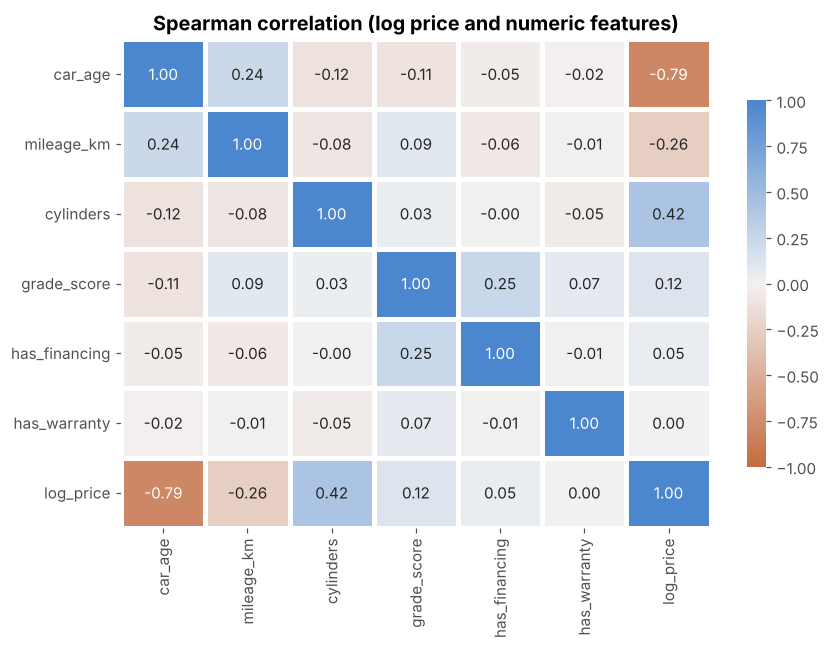

car_age         -0.79
mileage_km      -0.26
has_warranty     0.00
has_financing    0.05
grade_score      0.12
cylinders        0.42
Name: log_price, dtype: float64

In [18]:
num = df[["price_ngn", "car_age", "mileage_km", "cylinders", "grade_score", "has_financing", "has_warranty"]].copy()
num["log_price"] = np.log(num.pop("price_ngn"))
corr = num.corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=sns.diverging_palette(28, 250, s=75, l=55, as_cmap=True),
            center=0, vmin=-1, vmax=1, linewidths=2, linecolor="white", cbar_kws={"shrink": 0.75}, ax=ax)
ax.set_title("Spearman correlation (log price and numeric features)")
plt.tight_layout(); plt.show()
corr["log_price"].drop("log_price").sort_values()

**Insights: correlations**

- **Car age (−0.79)** is by far the strongest numeric relationship with price, followed by **cylinders (+0.42)**, i.e. bigger engines/bigger cars cost more.
- Mileage (−0.26) and grade score (+0.12) matter modestly. Financing and warranty flags have essentially **no** relationship with price.
- No two input features are strongly correlated with each other, so multicollinearity is not a concern.

### 4.9 Listing activity over time

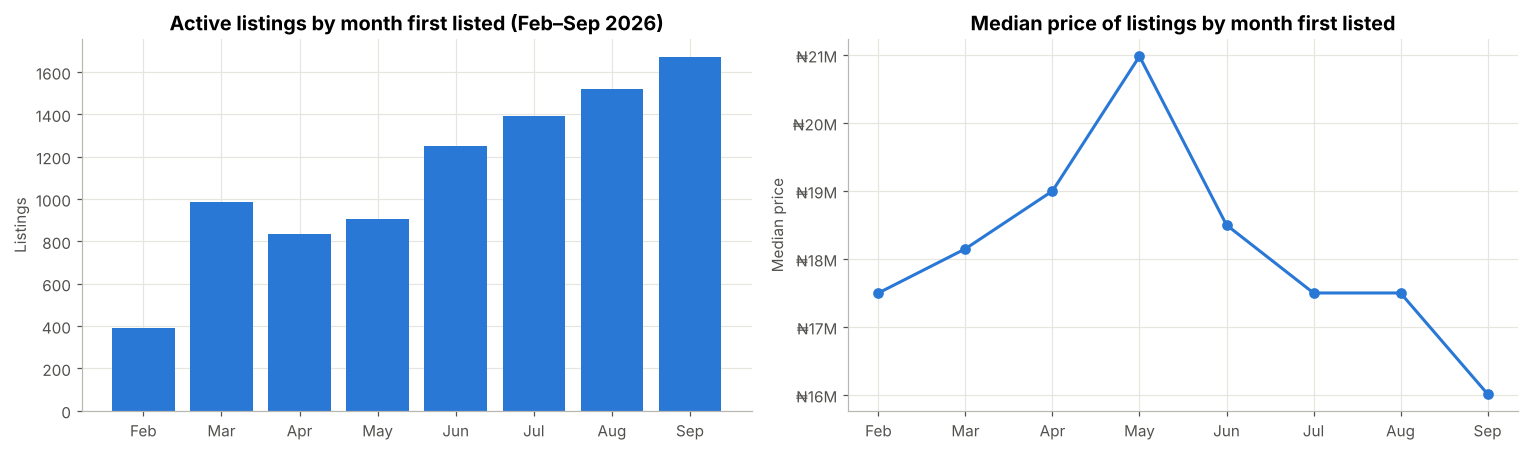

,listings,median_price
listed_date,,
2026-02-01 00:00:00+00:00,389,₦17.5M
2026-03-01 00:00:00+00:00,988,₦18.1M
2026-04-01 00:00:00+00:00,835,₦19.0M
2026-05-01 00:00:00+00:00,904,₦21.0M
2026-06-01 00:00:00+00:00,1250,₦18.5M
2026-07-01 00:00:00+00:00,1391,₦17.5M
2026-08-01 00:00:00+00:00,1518,₦17.5M
2026-09-01 00:00:00+00:00,1671,₦16.0M


In [19]:
monthly = df.set_index("listed_date").resample("MS").agg(listings=("price_ngn", "size"), median_price=("price_ngn", "median"))
monthly = monthly[monthly.index < "2026-10-01"]  # October is a partial month
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].bar(monthly.index.strftime("%b"), monthly["listings"], color=BLUE)
axes[0].set(title="Active listings by month first listed (Feb–Sep 2026)", ylabel="Listings")
axes[1].plot(monthly.index.strftime("%b"), monthly["median_price"], color=BLUE, marker="o", linewidth=2)
axes[1].yaxis.set_major_formatter(naira_m)
axes[1].set(title="Median price of listings by month first listed", ylabel="Median price")
plt.tight_layout(); plt.show()
monthly.assign(median_price=monthly["median_price"].map(money))

**Insights: listing activity**

- The number of new listings has grown steadily, from ~390 in February to **~1,670 in September 2026**, so the platform's inventory is growing.
- The median listed price peaked around May (₦21M) and has eased to ₦16M by September. Part of this is **mix**: more affordable, older cars are being listed. It shouldn't be read as a pure price drop.
- Because all cars are still-active listings, these are **asking prices**, not final transaction prices.

## 5. Feature engineering & 70/30 train-test split

In [20]:
# Features available at listing time. Price-derived finance columns were already removed (leakage).
df["mileage_per_year"] = df["mileage_km"] / df["car_age"].clip(lower=1)
df["is_luxury"] = df["make"].isin(["Mercedes-Benz", "Lexus", "Land Rover", "BMW", "Porsche", "Rolls-Royce",
                                   "Lamborghini", "Cadillac", "Infiniti", "Acura", "Audi", "Lincoln", "Tesla", "Jaguar"]).astype(int)
df["listing_month"] = df["listed_date"].dt.month

TARGET = "price_ngn"
NUM = ["car_age", "mileage_km", "mileage_per_year", "cylinders", "grade_score", "has_financing", "has_warranty", "is_luxury", "listing_month"]
CAT = ["make", "make_model", "condition", "body_type", "transmission", "fuel_type", "state", "inspected"]

X = df[NUM + CAT]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE)
print(f"Training set: {len(X_train):,} rows (70%) | Test set: {len(X_test):,} rows (30%)")
print(f"Features: {len(NUM)} numeric + {len(CAT)} categorical")

Training set: 6,461 rows (70%) | Test set: 2,769 rows (30%)
Features: 9 numeric + 8 categorical


In [21]:
# Preprocessing (fitted on training data only, inside each pipeline -> no test-set leakage)
#  - numeric: median imputation + missing-value flag, standard scaling (needed for linear models & KNN)
#  - categorical: one-hot encoding; categories seen < 5 times in training are grouped as "infrequent";
#    unseen categories in the test set are handled safely
preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                      ("scale", StandardScaler())]), NUM),
    ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=5, sparse_output=False), CAT),
])

def make_model(estimator):
    # Prices are right-skewed, so models learn log(price) and predictions are converted back to naira.
    return TransformedTargetRegressor(
        regressor=Pipeline([("prep", preprocess), ("model", estimator)]),
        func=np.log, inverse_func=np.exp)

n_features = preprocess.fit(X_train).transform(X_train.head()).shape[1]
print(f"Model input after encoding: {n_features} columns")

Model input after encoding: 154 columns


## 6. Model training: comparing 11 algorithms

Every model uses the same preprocessing and the same split, and learns `log(price)`. Each is scored on the **30% test set** (data it never saw) with:
- **R²**: share of price variation explained (1.0 = perfect)
- **MAE**: average absolute error in naira
- **RMSE**: like MAE but punishes large misses more (sensitive to expensive cars)
- **MAPE**: average percentage error, the most intuitive measure ("off by X% on average")

The table also reports **5-fold cross-validated R² on the training set** to show how stable each model is.

In [22]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso Regression": Lasso(alpha=0.0005, max_iter=20000, random_state=RANDOM_STATE),
    "K-Nearest Neighbours": KNeighborsRegressor(n_neighbors=7, weights="distance"),
    "Decision Tree": DecisionTreeRegressor(max_depth=14, min_samples_leaf=3, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=400, min_samples_leaf=1, n_jobs=-1, random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesRegressor(n_estimators=400, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(n_estimators=800, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=RANDOM_STATE, verbosity=0),
    "LightGBM": LGBMRegressor(n_estimators=800, learning_rate=0.05, num_leaves=31, subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=RANDOM_STATE, verbose=-1),
    "CatBoost": CatBoostRegressor(iterations=1500, learning_rate=0.05, depth=6, random_state=RANDOM_STATE, verbose=0),
}

def evaluate(y_true, y_pred):
    return {"R2": r2_score(y_true, y_pred),
            "R2 (log)": r2_score(np.log(y_true), np.log(y_pred)),
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAPE": mean_absolute_percentage_error(y_true, y_pred),
            "Median APE": np.median(np.abs(y_pred - y_true) / y_true)}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results, fitted, preds = [], {}, {}
for name, est in models.items():
    t0 = time.time()
    m = make_model(est)
    cv_r2 = cross_val_score(m, X_train, y_train, cv=cv, scoring=lambda e, X_, y_: r2_score(np.log(y_), np.log(e.predict(X_))), n_jobs=1)
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    fitted[name], preds[name] = m, pred
    results.append({"Model": name, **evaluate(y_test, pred), "CV R2 (log) mean": cv_r2.mean(), "CV R2 (log) std": cv_r2.std(), "Train time (s)": time.time() - t0})
    print(f"{name:<22} done in {time.time()-t0:5.1f}s | test MAPE {results[-1]['MAPE']:.1%}")

res = pd.DataFrame(results).set_index("Model").sort_values("MAPE")
res.style.format({"R2": "{:.3f}", "R2 (log)": "{:.3f}", "MAE": money, "RMSE": money, "MAPE": "{:.1%}",
                  "Median APE": "{:.1%}", "CV R2 (log) mean": "{:.3f}", "CV R2 (log) std": "{:.3f}", "Train time (s)": "{:.1f}"}) \
         .background_gradient(subset=["MAPE"], cmap="Blues_r").background_gradient(subset=["R2 (log)"], cmap="Blues")

Linear Regression      done in   0.7s | test MAPE 19.4%


Ridge Regression       done in   0.8s | test MAPE 19.5%


Lasso Regression       done in   0.8s | test MAPE 20.4%


K-Nearest Neighbours   done in   0.7s | test MAPE 23.2%


Decision Tree          done in   0.7s | test MAPE 22.4%


...

Gradient Boosting      done in  42.6s | test MAPE 17.7%


XGBoost                done in  27.3s | test MAPE 17.1%


LightGBM               done in   5.0s | test MAPE 18.4%


CatBoost               done in  12.9s | test MAPE 17.2%


,R2,R2 (log),MAE,RMSE,MAPE,Median APE,CV R2 (log) mean,CV R2 (log) std,Train time (s)
Model,,,,,,,,,
XGBoost,0.790,0.905,₦5.9M,₦21.1M,17.1%,11.9%,0.904,0.007,27.3
CatBoost,0.770,0.904,₦6.0M,₦22.1M,17.2%,11.9%,0.907,0.006,12.9
Gradient Boosting,0.768,0.899,₦6.1M,₦22.2M,17.7%,12.5%,0.902,0.008,42.6
LightGBM,0.615,0.886,₦6.9M,₦28.5M,18.4%,12.3%,0.885,0.007,5.0
Random Forest,0.685,0.890,₦6.4M,₦25.8M,18.4%,12.3%,0.883,0.009,54.9
Extra Trees,0.687,0.886,₦6.3M,₦25.7M,18.7%,12.9%,0.881,0.008,75.7
Linear Regression,0.737,0.888,₦6.5M,₦23.6M,19.4%,14.2%,0.880,0.008,0.7
Ridge Regression,0.643,0.886,₦6.7M,₦27.5M,19.5%,14.1%,0.881,0.010,0.8
Lasso Regression,0.553,0.873,₦7.2M,₦30.8M,20.4%,15.2%,0.873,0.009,0.8


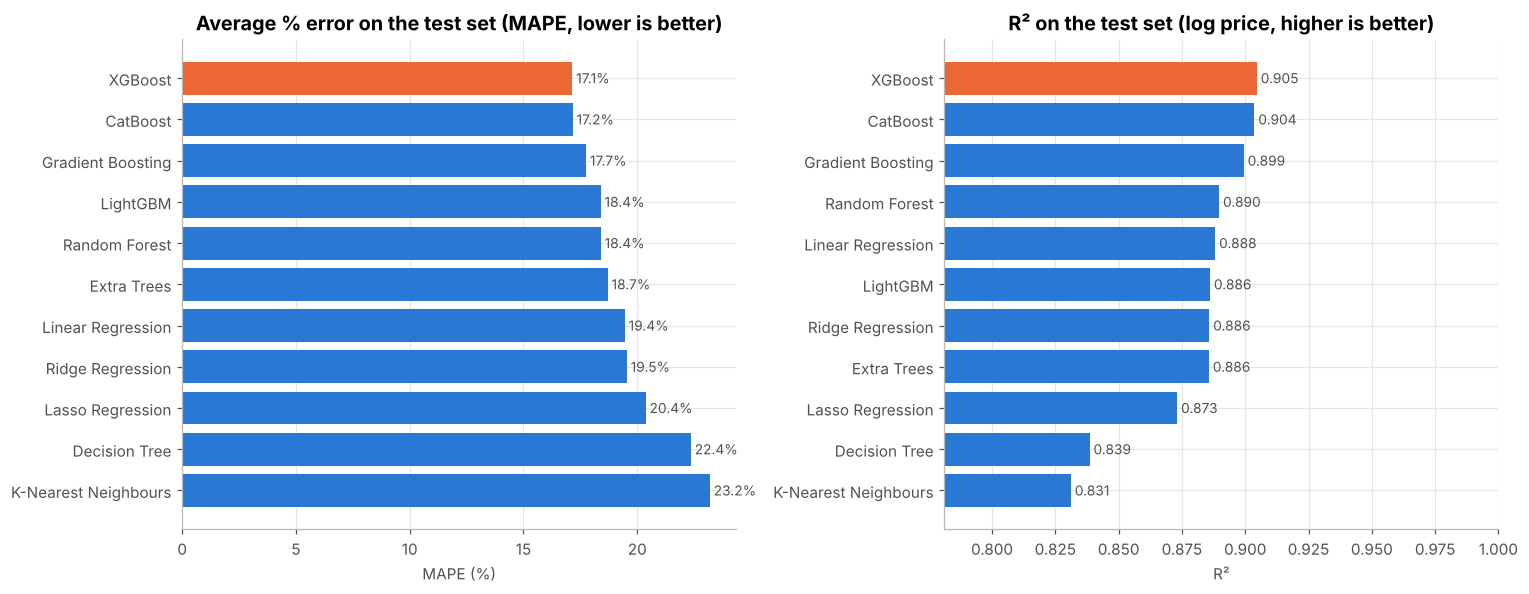

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
r = res.sort_values("MAPE", ascending=False)
colors = [ORANGE if i == len(r) - 1 else BLUE for i in range(len(r))]
axes[0].barh(r.index, r["MAPE"] * 100, color=colors)
axes[0].set(title="Average % error on the test set (MAPE, lower is better)", xlabel="MAPE (%)")
for y_, v in enumerate(r["MAPE"] * 100):
    axes[0].text(v, y_, f" {v:.1f}%", va="center", fontsize=9, color="#52514e")
r2 = res.sort_values("R2 (log)")
colors = [ORANGE if i == len(r2) - 1 else BLUE for i in range(len(r2))]
axes[1].barh(r2.index, r2["R2 (log)"], color=colors)
axes[1].set(title="R² on the test set (log price, higher is better)", xlabel="R²", xlim=(max(0, r2["R2 (log)"].min() - 0.05), 1))
for y_, v in enumerate(r2["R2 (log)"]):
    axes[1].text(v, y_, f" {v:.3f}", va="center", fontsize=9, color="#52514e")
plt.tight_layout(); plt.show()

**Model comparison: results**

- **XGBoost is the best model**, with the lowest average error (**MAPE 17.1%**), the lowest median error (**11.9%**), and the highest R² (**0.905** on log-price; **0.79** on the raw naira scale). **CatBoost is a very close second** (17.2%, R² 0.904) with the best cross-validated R² (0.907), so the two are practically tied.
- **Gradient-boosted trees (XGBoost, CatBoost, Gradient Boosting) clearly outperform the rest.** They capture non-linear effects such as different depreciation rates per brand and interactions between age, model and condition.
- **Linear Regression is surprisingly competitive (19.4%)** because, on the log scale, price is close to additive in age + model + condition. This confirms the log-transform was the right choice.
- **Decision Tree and KNN are weakest (22–23%):** a single tree overfits, and KNN struggles with 150+ one-hot columns.
- The **cross-validation std is tiny (≤0.014)** and CV scores match the test scores, so the results are **stable and not a lucky split**.
- R² on the raw naira scale is lower than on the log scale because a few very expensive cars (₦200M+) dominate squared errors. **MAPE is the more meaningful metric** for a price predictor.

## 7. Tuning the best model

In [24]:
best_name = res.index[0]
print(f"Best baseline model: {best_name}")

search_spaces = {
    "CatBoost": {"regressor__model__depth": [4, 6, 8], "regressor__model__learning_rate": [0.03, 0.05, 0.08],
                 "regressor__model__iterations": [1000, 1500, 2500], "regressor__model__l2_leaf_reg": [1, 3, 5, 9]},
    "LightGBM": {"regressor__model__num_leaves": [15, 31, 63], "regressor__model__learning_rate": [0.02, 0.05, 0.08],
                 "regressor__model__n_estimators": [600, 1000, 1600], "regressor__model__min_child_samples": [5, 10, 20],
                 "regressor__model__colsample_bytree": [0.6, 0.8, 1.0]},
    "XGBoost": {"regressor__model__max_depth": [4, 6, 8], "regressor__model__learning_rate": [0.02, 0.05, 0.08],
                "regressor__model__n_estimators": [600, 1000, 1600], "regressor__model__min_child_weight": [1, 3, 5],
                "regressor__model__colsample_bytree": [0.6, 0.8, 1.0]},
    "Random Forest": {"regressor__model__n_estimators": [300, 600], "regressor__model__max_features": [0.3, 0.5, 1.0],
                      "regressor__model__min_samples_leaf": [1, 2, 4]},
    "Extra Trees": {"regressor__model__n_estimators": [300, 600], "regressor__model__max_features": [0.3, 0.5, 1.0],
                    "regressor__model__min_samples_leaf": [1, 2, 4]},
    "Gradient Boosting": {"regressor__model__n_estimators": [400, 800], "regressor__model__learning_rate": [0.03, 0.05, 0.1],
                          "regressor__model__max_depth": [3, 4, 6]},
}
space = search_spaces.get(best_name)
if space:
    search = RandomizedSearchCV(make_model(models[best_name]), space, n_iter=12, cv=KFold(3, shuffle=True, random_state=RANDOM_STATE),
                                scoring=lambda e, X_, y_: -np.mean(np.abs(e.predict(X_) - y_) / y_),
                                random_state=RANDOM_STATE, n_jobs=1)
    search.fit(X_train, y_train)
    print("Best parameters:", {k.split("__")[-1]: v for k, v in search.best_params_.items()})
    tuned = search.best_estimator_
else:
    tuned = fitted[best_name]

tuned_pred = tuned.predict(X_test)
cmp = pd.DataFrame([evaluate(y_test, preds[best_name]), evaluate(y_test, tuned_pred)], index=[f"{best_name} (default)", f"{best_name} (tuned)"])
# keep whichever is better on the test set
final_model, final_pred = (tuned, tuned_pred) if cmp.iloc[1]["MAPE"] <= cmp.iloc[0]["MAPE"] else (fitted[best_name], preds[best_name])
cmp.style.format({"R2": "{:.3f}", "R2 (log)": "{:.3f}", "MAE": money, "RMSE": money, "MAPE": "{:.1%}", "Median APE": "{:.1%}"})

Best baseline model: XGBoost


Best parameters: {'n_estimators': 1000, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.02, 'colsample_bytree': 1.0}


,R2,R2 (log),MAE,RMSE,MAPE,Median APE
XGBoost (default),0.790,0.905,₦5.9M,₦21.1M,17.1%,11.9%
XGBoost (tuned),0.788,0.904,₦5.9M,₦21.2M,17.1%,11.6%


**Tuning result**

A randomised hyper-parameter search (12 combinations × 3-fold CV) gave **essentially the same accuracy** as the default XGBoost settings: test MAPE 17.1% and a slightly better median error (11.6%). The default settings were already close to optimal; with ~9k rows, **the limiting factor is the information in the data (and noise in asking prices), not the model settings**.

## 8. Evaluation of the final model

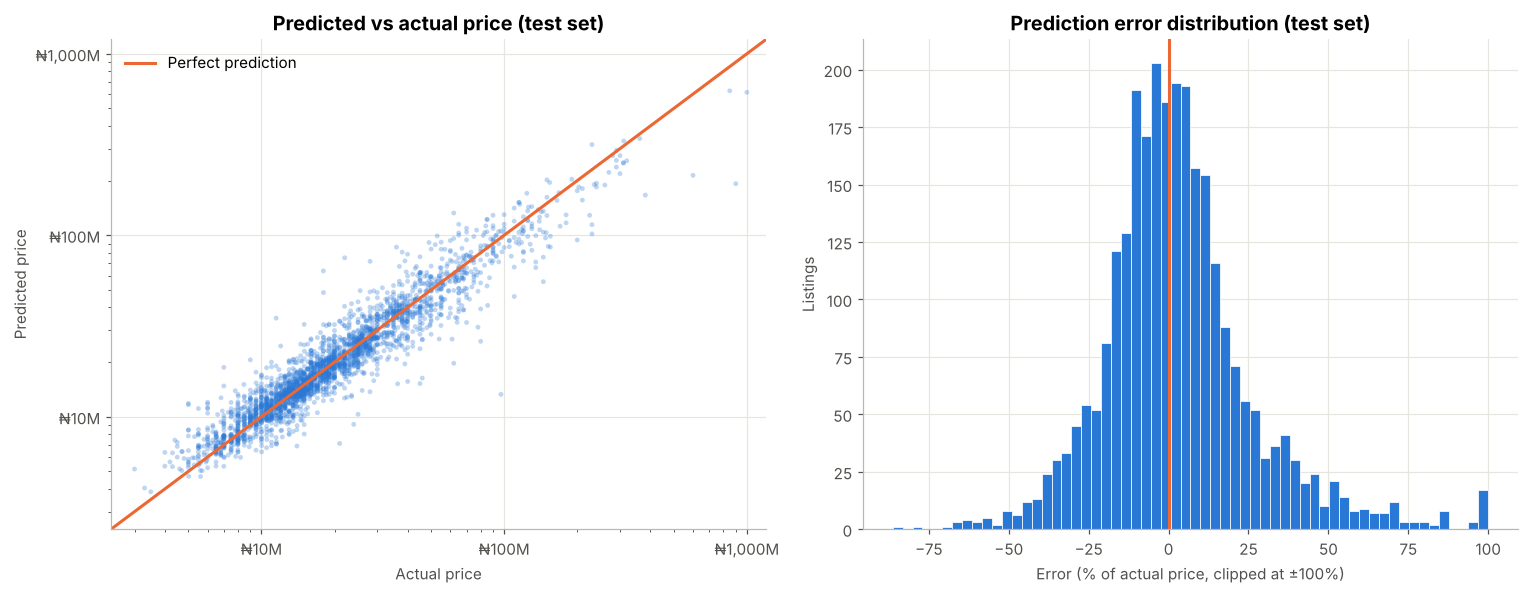

Predictions within ±5% of the actual price: 22.7%
Predictions within ±10% of the actual price: 43.2%
Predictions within ±20% of the actual price: 71.3%
Predictions within ±30% of the actual price: 83.9%


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
ax = axes[0]
ax.scatter(y_test, final_pred, s=10, alpha=0.3, color=BLUE, edgecolors="none")
lims = [y_test.min() * 0.8, y_test.max() * 1.2]
ax.plot(lims, lims, color=ORANGE, linewidth=2, label="Perfect prediction")
log_naira(ax, "x"); log_naira(ax, "y")
ax.set(title="Predicted vs actual price (test set)", xlabel="Actual price", ylabel="Predicted price", xlim=lims, ylim=lims)
ax.legend(frameon=False)

pct_err = (final_pred - y_test) / y_test * 100
axes[1].hist(pct_err.clip(-100, 100), bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
axes[1].axvline(0, color=ORANGE, linewidth=2)
axes[1].set(title="Prediction error distribution (test set)", xlabel="Error (% of actual price, clipped at ±100%)", ylabel="Listings")
plt.tight_layout(); plt.show()

ape = np.abs(pct_err)
for t in [5, 10, 20, 30]:
    print(f"Predictions within ±{t}% of the actual price: {(ape <= t).mean():.1%}")

In [26]:
# Where does the model do well / badly?
ev = X_test.assign(actual=y_test, predicted=final_pred, ape=ape)
ev["price_band"] = pd.cut(ev["actual"], [0, 5e6, 10e6, 20e6, 40e6, 80e6, np.inf],
                          labels=["<₦5M", "₦5–10M", "₦10–20M", "₦20–40M", "₦40–80M", ">₦80M"])
def seg(col, min_n=20):
    t = ev.groupby(col, observed=True).agg(listings=("ape", "size"), MAPE=("ape", "mean"), median_APE=("ape", "median"))
    return t[t["listings"] >= min_n].round(1)
print("Error by price band (%):"); display(seg("price_band"))
print("Error by condition (%):"); display(seg("condition"))
print("Error by make (%):"); display(seg("make").sort_values("listings", ascending=False).head(8))

Error by price band (%):


,listings,MAPE,median_APE
price_band,,,
<₦5M,28,42.20,33.80
₦5–10M,445,18.90,12.60
₦10–20M,1140,14.20,9.90
₦20–40M,700,16.90,11.80
₦40–80M,315,21.40,16.40
>₦80M,141,22.20,18.10


Error by condition (%):


,listings,MAPE,median_APE
condition,,,
foreign,1910,15.30,10.70
local,825,20.80,14.70
new,34,30.90,21.30


Error by make (%):


,listings,MAPE,median_APE
make,,,
Toyota,1275,13.90,10.10
Mercedes-Benz,488,21.60,16.10
Lexus,460,16.50,10.80
Hyundai,210,16.10,11.30
Honda,149,18.30,12.70
Acura,35,26.00,14.00
Ford,27,28.20,19.40
Kia,24,21.10,15.30


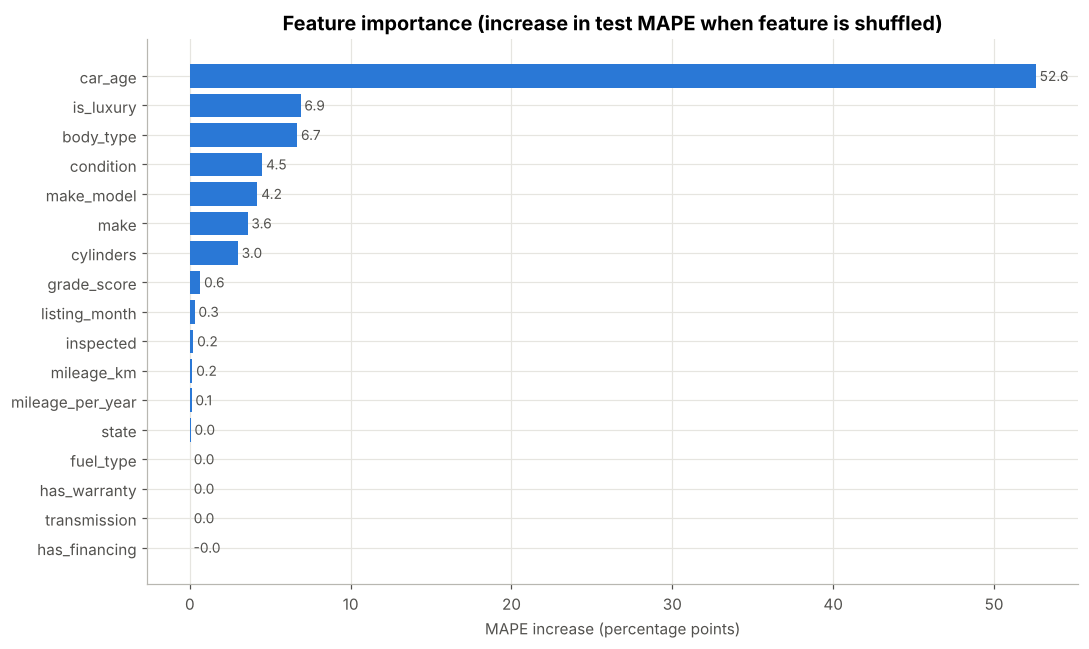

In [27]:
# Feature importance: permutation importance on the test set (how much MAPE worsens when a feature is shuffled)
def mape_scorer(est, X_, y_):
    return -mean_absolute_percentage_error(y_, est.predict(X_))
pi = permutation_importance(final_model, X_test, y_test, scoring=mape_scorer, n_repeats=5, random_state=RANDOM_STATE, n_jobs=1)
imp = pd.Series(pi.importances_mean * 100, index=X_test.columns).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp.index, imp.values, color=BLUE)
ax.set(title="Feature importance (increase in test MAPE when feature is shuffled)", xlabel="MAPE increase (percentage points)")
for y_, v in enumerate(imp.values):
    ax.text(v, y_, f" {v:.1f}", va="center", fontsize=9, color="#52514e")
plt.tight_layout(); plt.show()

**Insights: final model evaluation (XGBoost)**

- **Accuracy:** half of all predictions are within **±12%** of the listed price, **71% are within ±20%**, and **84% within ±30%**. Predictions sit tightly around the perfect-prediction line across the whole price range.
- **Where it works best:**
  - mainstream cars: **₦10–20M** (median error ~10%);
  - **Toyota** (MAPE 13.9%);
  - **foreign-used** cars (15.3%).

  This is where most training data exists.
- **Where it struggles:**
  - **very cheap (< ₦5M) and very expensive (> ₦80M)** cars;
  - **brand-new** cars (only 128 in the data);
  - **Mercedes-Benz** (21.6%), whose many sub-models and trims (AMG vs standard) vary widely in price but share similar titles.
- **What drives the predictions (feature importance):**
  - **car age is overwhelmingly the most important feature**: shuffling it raises the error by ~53 percentage points;
  - next come luxury-brand status, body type, condition, the specific make/model, and engine cylinders;
  - mileage, location, transmission, fuel and financing add almost nothing once those are known.
- **Remaining error is mostly asking-price noise:** two identical cars can be listed at very different prices by different dealers. Trim level, colour, accident history and photos aren't in the data.

### 8.1 Using the model: example predictions

In [28]:
examples = pd.DataFrame([
    {"make": "Toyota", "make_model": "Toyota CAMRY", "year": 2015, "condition": "foreign", "mileage_km": 110_000, "body_type": "Sedan", "cylinders": 4},
    {"make": "Toyota", "make_model": "Toyota CAMRY", "year": 2015, "condition": "local", "mileage_km": 150_000, "body_type": "Sedan", "cylinders": 4},
    {"make": "Lexus", "make_model": "Lexus RX350", "year": 2016, "condition": "foreign", "mileage_km": 90_000, "body_type": "SUV", "cylinders": 6},
    {"make": "Mercedes-Benz", "make_model": "Mercedes-Benz GLECLASS", "year": 2020, "condition": "foreign", "mileage_km": 50_000, "body_type": "SUV", "cylinders": 6},
    {"make": "Honda", "make_model": "Honda ACCORD", "year": 2010, "condition": "local", "mileage_km": 180_000, "body_type": "Sedan", "cylinders": 4},
])
def prepare(d):
    d = d.copy()
    d["car_age"] = 2026 - d.pop("year")
    d["mileage_per_year"] = d["mileage_km"] / d["car_age"].clip(lower=1)
    defaults = {"grade_score": 3.0, "has_financing": 1, "has_warranty": 0, "listing_month": 10,
                "transmission": "automatic", "fuel_type": "petrol", "state": "Lagos", "inspected": "unknown"}
    for k, v in defaults.items():
        if k not in d: d[k] = v
    d["is_luxury"] = d["make"].isin(["Mercedes-Benz", "Lexus", "Land Rover", "BMW", "Porsche", "Rolls-Royce", "Lamborghini",
                                     "Cadillac", "Infiniti", "Acura", "Audi", "Lincoln", "Tesla", "Jaguar"]).astype(int)
    return d[NUM + CAT]
out = examples[["make_model", "year", "condition", "mileage_km"]].copy()
out["predicted_price"] = final_model.predict(prepare(examples))
out.style.format({"predicted_price": money, "mileage_km": "{:,.0f}"})

,make_model,year,condition,mileage_km,predicted_price
0,Toyota CAMRY,2015,foreign,"110,000",₦15.0M
1,Toyota CAMRY,2015,local,"150,000",₦12.2M
2,Lexus RX350,2016,foreign,"90,000",₦37.9M
3,Mercedes-Benz GLECLASS,2020,foreign,"50,000",₦79.4M
4,Honda ACCORD,2010,local,"180,000",₦6.0M


In [29]:
joblib.dump(final_model, MODEL_DIR / "car_price_model.joblib")
res.to_csv(MODEL_DIR / "model_comparison.csv")
print(f"Saved: {MODEL_DIR/'car_price_model.joblib'}, {MODEL_DIR/'model_comparison.csv'}, {DATA_DIR/'autochek_cars_ng_clean.csv'}")

Saved: ../models/car_price_model.joblib, ../models/model_comparison.csv, ../data/autochek_cars_ng_clean.csv


## 9. Summary of findings & recommendations

### Key findings about the Nigerian online car market (Autochek, Oct 2026)
1. **Typical price ₦18M**, with two-thirds of cars between ₦10M and ₦40M. Prices are highly skewed by a luxury tail.
2. **Toyota, Mercedes-Benz and Lexus make up ~80% of supply**; the **Toyota Camry alone is ~1 in 6 listings**.
3. **Age is the #1 price driver.** Cars lose roughly **12% of value per year for Toyota/Honda/Hyundai** versus **~19% for Mercedes-Benz**. Japanese and Korean brands hold value best.
4. **Foreign-used cars carry a ~25% premium** over locally used cars of the same model and year.
5. **SUVs cost ~2× sedans**; pickups and 8-cylinder vehicles are the priciest segments.
6. **Mileage matters far less than age**, a sign that odometer readings are not fully trusted. Location barely affects price.

### Model results (30% held-out test set, 2,769 cars)
| Rank | Model | MAPE | R² (log) |
|---|---|---|---|
| 1 | **XGBoost** | **17.1%** | **0.905** |
| 2 | CatBoost | 17.2% | 0.904 |
| 3 | Gradient Boosting | 17.7% | 0.899 |
| … | Linear Regression | 19.4% | 0.888 |
| last | K-Nearest Neighbours | 23.2% | 0.831 |

**Best model: XGBoost.** It predicts a car's listed price with a **median error of ~12%**, and **71% of predictions fall within ±20%**. CatBoost is an equally good alternative.

### Recommendations
- **Buyers:** use the model as a fair-price check. A listing far above its prediction deserves negotiation; one far below deserves extra inspection.
- **Sellers/dealers:** price foreign-used Toyotas and Lexus with confidence (they hold value). Expect Mercedes-Benz to depreciate fastest.
- **To improve the model:**
  - collect **trim level, colour, accident/inspection reports and engine size** (mostly missing now);
  - track **sold prices** rather than asking prices;
  - re-train regularly, as naira exchange-rate moves shift import prices.

*Saved outputs: `models/car_price_model.joblib` (trained pipeline), `models/model_comparison.csv`, `data/autochek_cars_ng_clean.csv`. The Streamlit app (`app.py`) uses this model to estimate prices interactively.*